*Deep Learning Project 1* : **CIFAR 10 Dataset Image Classification using Neural Networks**

In [ ]:
from datasets import load_dataset

ds = load_dataset("mteb/cifar10")

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [ ]:
ds['train'].column_names

['img', 'label']

In [ ]:
train_subset = ds['train'].select_columns(["img","label"])

In [ ]:
train_subset['img']

Column([<PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x7AC6377EC2F0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x7AC6377EDAC0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x7AC6377EF2F0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x7AC6377EC9B0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x7AC638FEB170>])

In [ ]:
labels = train_subset['label']

In [ ]:
ds['train'].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [ ]:
ds['train'].features['label'].dtype

'int64'

In [ ]:
classes = ds['train'].features['label'].names

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [ ]:
def show_images_pil(img_list, n_rows=2, n_cols=5, titles=None):
    plt.figure(figsize=(2*n_cols, 2*n_rows))
    for i, img in enumerate(img_list[:n_rows * n_cols]):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)          # img is a PIL.PngImageFile
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()


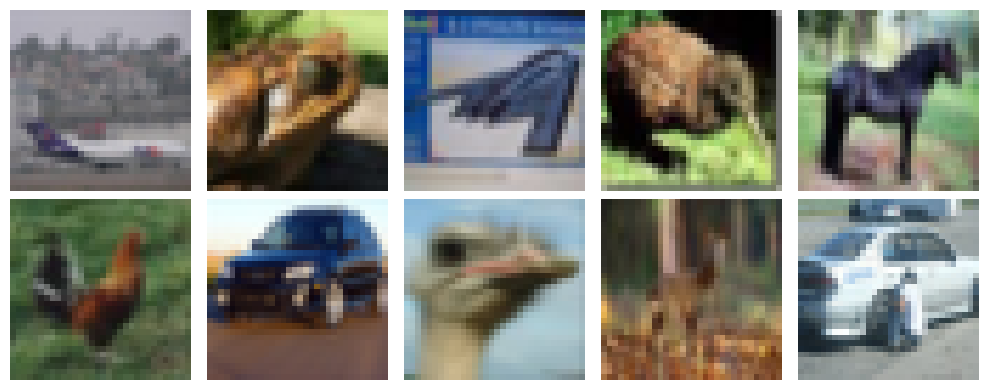

airplane -- frog -- airplane -- bird -- horse
bird -- automobile -- bird -- deer -- automobile


In [ ]:
# imgs is a list of PIL.PngImagePlugin.PngImageFile
show_images_pil(train_subset['img'], n_rows=2, n_cols=5)
print(" -- ".join(f"{classes[labels[j]]}" for j in range(5)))
print(" -- ".join(f"{classes[labels[j]]}" for j in range(5,10)))


In [ ]:
for i in range(10):
  print(classes[i])

airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck


In [ ]:
from collections import Counter

label_counts = Counter(labels)
print(label_counts)


Counter({0: 5000, 6: 5000, 2: 5000, 7: 5000, 1: 5000, 4: 5000, 5: 5000, 3: 5000, 8: 5000, 9: 5000})


In [ ]:
len(train_subset['label'])

50000

CIFAR Dataset is perfectly balanced dataset with equal number of images per class

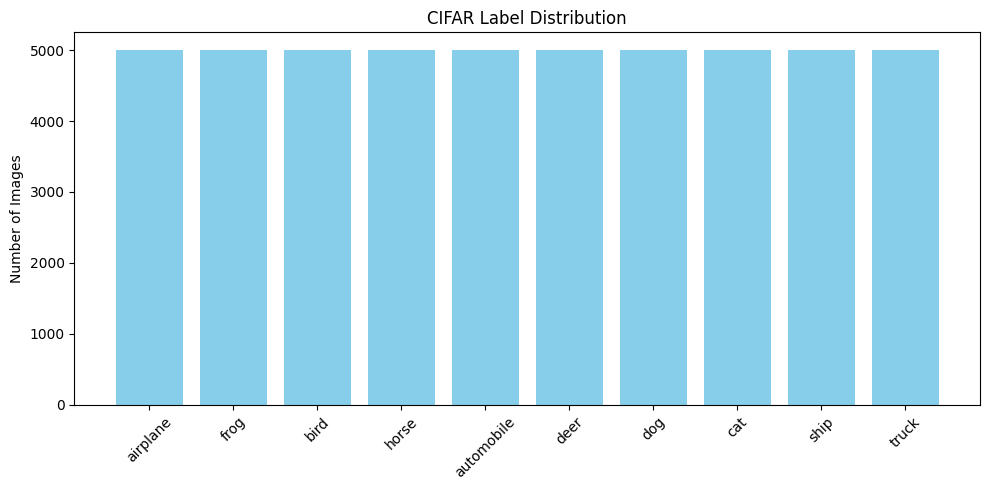

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
x = list(label_counts.keys())
y = [label_counts[i] for i in x]
names = [classes[i] for i in x]

plt.figure(figsize=(10, 5))
plt.bar(names, y, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.title("CIFAR Label Distribution")
plt.tight_layout()
plt.show()


Show Images with label == 0 (Airplane)

In [ ]:
airplane_subset = train_subset.filter(lambda x: x["label"] in [0])


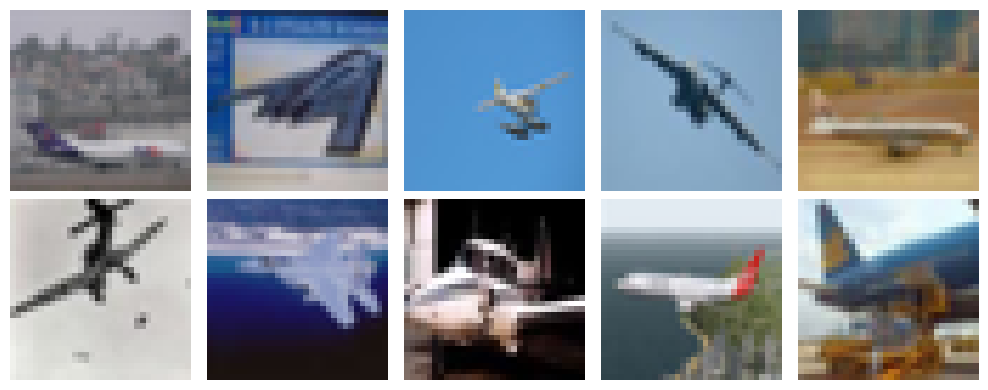

In [ ]:
show_images_pil(airplane_subset['img'], n_rows=2, n_cols=5)

In [ ]:
ref_img = airplane_subset['img'][0]   # PIL.PngImageFile

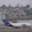

In [ ]:
ref_img

In [ ]:
import numpy as np

ref_arr = np.array(ref_img)

matches = []
for img in airplane_subset['img']:
    if np.array_equal(np.array(img), ref_arr):

        matches.append(img)
print("Number of identical images:", len(matches))




Number of identical images: 1


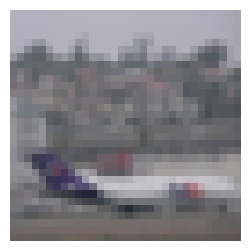

In [ ]:
# visualize all matches
plt.figure(figsize=(12, 3))

for i, img in enumerate(matches):
    plt.subplot(1, len(matches), i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()


**Leveraging Pytorch for train dataset to get baseline accuracy**

In [ ]:
import torch
import time
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

In [ ]:
# Set the random seed
torch.manual_seed(52)

In [141]:
# Load full CIFAR dataset and normalize the data
#transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip()
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5,0.5,0.5))])
full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_full_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [ ]:
# Create a smaller dataset by selecting a subset (e.g., 1000 samples) since training the full dataset is slow
small_dataset_size = 7000  # Specify the size of the smaller dataset
small_dataset = Subset(full_dataset, list(range(small_dataset_size)))
small_dataset_test = Subset(test_full_dataset, list(range(small_dataset_size)))

In [ ]:
# Create a DataLoader with smaller batch size for the subset
train_loader = DataLoader(small_dataset, batch_size=50, shuffle=True)

In [ ]:
test_loader = DataLoader(small_dataset_test,batch_size=50, shuffle=True)

In [ ]:
len(train_loader)

In [ ]:
len(test_loader)

In [ ]:
# Define model parameters for CIFAR10
n_x = 32 * 32 * 3  # Input size: 32x32 RGB images flattened to a 1D array
n_h1 = 256  # Number of neurons in the first hidden layer
n_h2 = 128  # Number of neurons in the second hidden layer
n_output = 10  # 10 output classes (for MNIST)
learning_rate = 0.02
epochs = 100  # Reduce the number of iterations

Define Functions

In [ ]:
# new test
def softmax(logits):
    # logits: (N, C)
    z = logits - logits.max(dim=1, keepdim=True).values  # stability trick
    exp = torch.exp(z)
    return exp / exp.sum(dim=1, keepdim=True)

In [ ]:
# Softmax function
def softmax(Z):
    E = torch.exp(Z)
    EXP = torch.sum(E, dim=0, keepdim=True)
    return E/EXP



In [ ]:
# new test
def cross_entropy_loss_from_logits(logits, y):
    """
    logits: (N, C)
    y: (N,) integer labels
    returns: (loss scalar, dlogits)
    """
    N, C = logits.shape
    probs = softmax(logits)

    eps = 1e-12
    correct_probs = probs[torch.arange(N), y]  # probability of correct class
    loss = (-torch.log(correct_probs + eps)).mean()
    #print(loss)

    # Add Regularizer to loss


    # gradient of loss w.r.t logits
    dlogits = probs.clone()
    dlogits[torch.arange(N), y] -= 1.0
    dlogits /= N
    return loss, dlogits

In [ ]:
# Cross-entropy loss
def cross_entropy_loss(A, y):
    eps = 1e-12
    return torch.sum(-y * torch.log(A + eps))/y.shape[1]


In [ ]:
# Built in connected layer
# import torch
# import torch.nn as nn

# # Create built-in fully connected layer
# fc = nn.Linear(in_features=3072, out_features=256)

# # Example input (batch of 128 images flattened)
# x = torch.randn(128, 3072)

# # Forward pass
# out = fc(x)

# print("Output shape:", out.shape)

class Linear:
    def __init__(self, in_features, out_features, weight_scale=0.01, device="cpu"):
        self.W = weight_scale * torch.randn(in_features, out_features, device=device)  # build it
        self.b = torch.zeros(out_features, device=device) # built in

        # gradients (filled during backward)
        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        # cache input for backward
        self.x = None

    def forward(self, x):
        # x: (N, D)
        self.x = x
        return x @ self.W + self.b  # (N, M)

    def backward(self, dout):
        # dout: (N, M)
        self.dW = self.x.t() @ dout          # (D, M)
        self.db = dout.sum(dim=0)            # (M,)
        dx = dout @ self.W.t()               # (N, D)
        return dx


In [ ]:
# defining Relu class for NN model
class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask

    def backward(self, dout):
        #print(f"dx shape:",dout.shape)
        #print(f"self mask shape:",self.mask.shape)
        return dout * self.mask

In [ ]:
# define NN model class with intitialization, forward & backward steps
class FCNet:
    def __init__(self, input_dim, hidden_dim, hidden_dim2, num_classes=10, device="cpu"):
        self.fc1 = Linear(input_dim, hidden_dim, device=device)
        self.relu = ReLU()
        # add drop
        self.drop1 = Dropout(p=0.4)
        #self.fc2 = Linear(hidden_dim, num_classes, device=device)
        self.fc2 = Linear(hidden_dim, hidden_dim2, device=device)
        self.relu2 = ReLU()
        # add drop
        self.drop2 = Dropout(p=0.4)
        self.fc3 = Linear(hidden_dim2, num_classes, device=device)

    def forward(self, x):
        # x: (N, 3, 32, 32)
        x = x.view(x.shape[0], -1)      # flatten
        x = self.fc1.forward(x)
        x = self.relu.forward(x)
        x = self.drop1.forward(x)
        x = self.fc2.forward(x)
        x = self.relu2.forward(x)
        x = self.drop2.forward(x)
        logits = self.fc3.forward(x)
        return logits

        #logits = self.fc2.forward(x)
        #return logits

    def backward(self, dlogits):
        dx = self.fc3.backward(dlogits)
        dx = self.drop2.backward(dx)

        dx = self.relu2.backward(dx)
        dx = self.fc2.backward(dx)
        dx = self.drop1.backward(dx)

        dx = self.relu.backward(dx)
        dx = self.fc1.backward(dx)
        return dx

    def params(self):
        # return list of parameters and grads for updating
        return [
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
            (self.fc3.W, self.fc3.dW),
            (self.fc3.b, self.fc3.db)
        ]

Regularizer 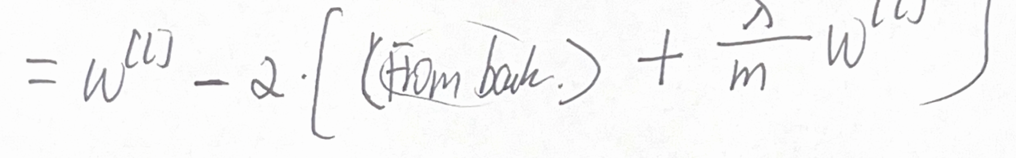

In [ ]:
def sgd_step(params, lr, lm):
    for p, dp in params:
        # apply regularizer
        if p.ndim == 2:          # only W
            dp += (lm * p)
        p -= lr * dp
#with torch.no_grad():
              #W1 -= learning_rate * W1.grad # W1
              #b1 -= learning_rate * b1.grad # b1
              #W2 -= learning_rate * W2.grad # W2
              #b2 -= learning_rate * b2.grad # b2
              #W3 -= learning_rate * W3.grad # W3
              #b3 -= learning_rate * b3.grad # b3

In [ ]:
@torch.no_grad()
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

In [ ]:
@torch.no_grad()
def evaluate(model, loader, device="cpu"):
    acc_sum = 0.0
    steps = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model.forward(xb)
        acc_sum += accuracy_from_logits(logits, yb)
        steps += 1
    return acc_sum / steps

![image.png](

)

In [ ]:
def l2_loss(model, lam):
    reg = 0.0
    for (p, dp) in model.params():
        if p.ndim == 2:          # only W
            reg += (p*p).sum()
    return 0.5*lam * reg


In [ ]:
class Dropout:
    def __init__(self, p=0.4):
        self.p = p
        self.mask = None
        self.training = True

    def forward(self, x):
        if not self.training:
            return x
        self.mask = (torch.rand_like(x) > self.p).float()
        return (x * self.mask) / (1 - self.p)

    def backward(self, grad_output):
        if not self.training:
            return grad_output
        return (grad_output * self.mask) / (1 - self.p)


In [ ]:
def train_fc(model, train_loader, test_loader, epochs, lr=0.02, device="cpu"):
    loss_history = []      # loss per iteration
    train_acc_hist = []    # train acc per epoch
    test_acc_hist = []     # test acc per epoch

    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        model.drop1.training = True
        model.drop2.training = True

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # forward
            logits = model.forward(xb)

            # for passing the parameter for regularizer
            #print(model.params()[0][0].shape)
            #print(model.params()[2][0].shape)
            #print(model.params()[4][0].shape)

            # loss + gradient start
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # apply regularizer loss
            #rl = (model.params()[0][0] ** 2).sum() + (model.params()[2][0] ** 2).sum() + (model.params()[4][0]**2).sum()
            #print(rl)
            loss += l2_loss(model, 0.0004)
            # loss + gradient end
            #
            # backward
            model.backward(dlogits)

            # update
            sgd_step(model.params(), lr, 0.0004)

            # log
            loss_history.append(loss.item())
            model_loss += loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        # epoch summary
        train_acc = model_acc / steps
        #print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f}")
        train_acc_hist.append(train_acc)

        model.drop1.training = False
        model.drop2.training = False

        # test accuracy
        test_acc = evaluate(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        if epoch % 10 == 0:
          print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist

In [ ]:
### Timing and execution ###
start_time = time.time()
model = FCNet(n_x, n_h1,n_h2)

cost_values, train_accuracy, test_accuracy = train_fc(model, train_loader, test_loader,epochs = 100,lr=0.02)
total_time = time.time() - start_time

In [ ]:
# Plotting comparison of training and test accuracy
import matplotlib.pyplot as plt

def plot_accuracy(train_acc, test_acc, title):
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, test_acc, label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


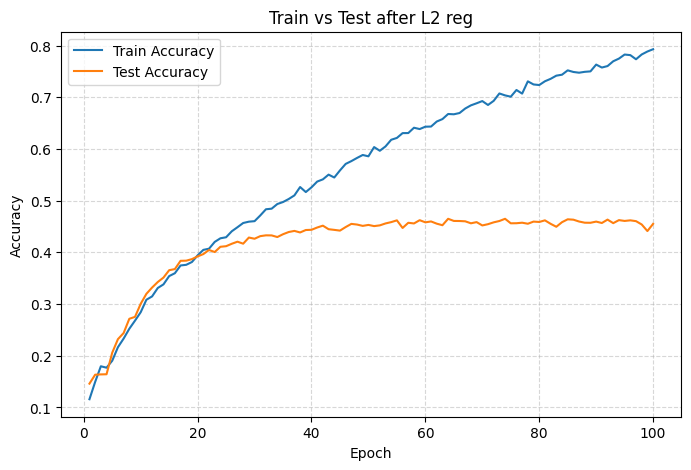

In [136]:
plot_accuracy(train_accuracy, test_accuracy, "Train vs Test after L2 reg")

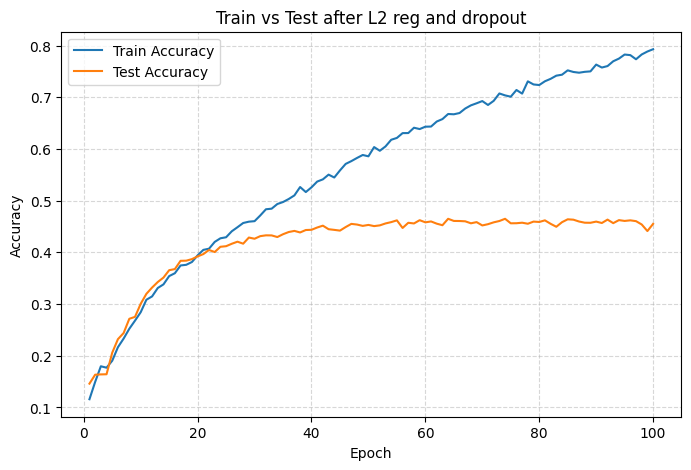

In [137]:
plot_accuracy(train_accuracy, test_accuracy, "Train vs Test after L2 reg and dropout")

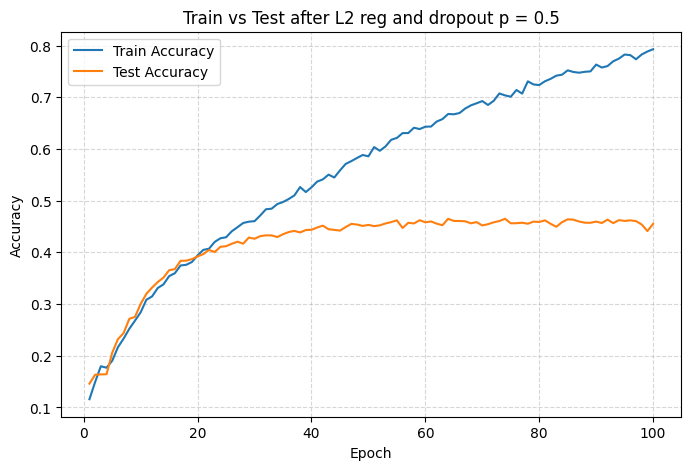

In [138]:
plot_accuracy(train_accuracy, test_accuracy, "Train vs Test after L2 reg and dropout p = 0.5")

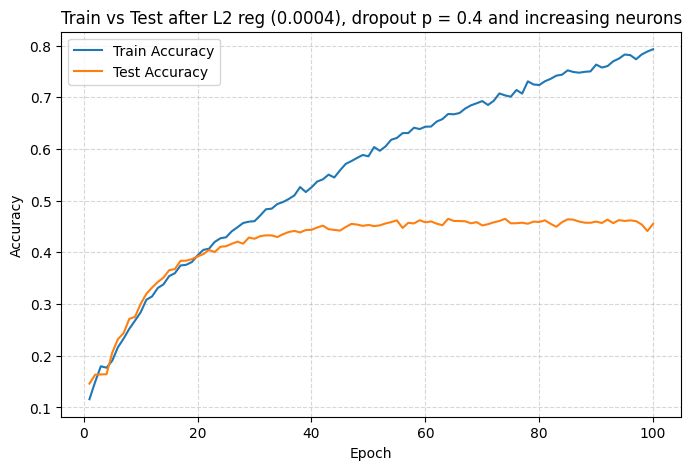

In [139]:
plot_accuracy(train_accuracy, test_accuracy, "Train vs Test after L2 reg (0.0004), dropout p = 0.4 and increasing neurons")

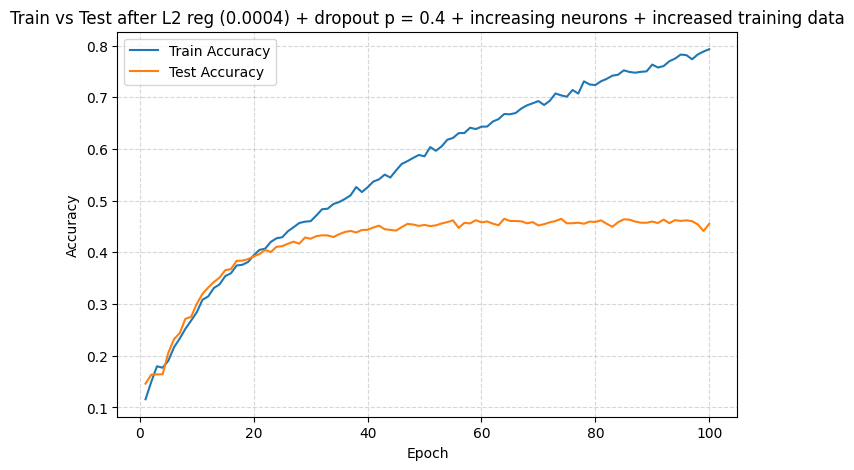

In [140]:
plot_accuracy(train_accuracy, test_accuracy, "Train vs Test after L2 reg (0.0004) + dropout p = 0.4 + increasing neurons + increased training data")

In [ ]:
# Plotting the cost value over iterations
plt.plot(range(len(cost_values)), cost_values)
plt.xlabel('Iterations')
plt.ylabel('Cost Value')
plt.title('Cost Value over Iterations (CIFAR10 Classification with Small Dataset)')
plt.tight_layout()
plt.savefig("cost_CIFAR10_small_dataset.png")

In [ ]:
print(f"Time: {total_time:.6f} seconds")
print(f"Final cost value: {cost_values[-1]:.6f}")

**Validate against test data**

In [ ]:
test_acc = evaluate(model, test_loader)

In [ ]:
def evaluate_model(W1, b1, W2, b2, W3, b3):
    correct = 0
    total = 0

    for images, labels in test_loader:
        # Flatten and transpose: (batch, 3,32,32) → (3072, batch)
        X = images.view(-1, 32*32*3).T

        # Forward pass
        probs = forward_pass(X, W1, b1, W2, b2, W3, b3)

        # Predicted class for each sample
        y_pred = probs.argmax(dim=0)   # dim=0 because shape = (10, batch)

        correct += (y_pred == labels).sum().item()
        total += labels.size(0)

    print(correct)
    print(total)

    accuracy = correct / total
    return accuracy


In [ ]:
test_acc = evaluate_model(W1_t, b1_t, W2_t, b2_t, W3_t, b3_t)
print("Test Accuracy:", test_acc)

Test acurracy with learning rate of 0.8 and 100 epochs: 28%

Try with adding regularizer and relu functions